## Bias-Variance Tradeoff

<img src="사진/fitting.png" alt="bias-variance"/>

y = ax + b(bias - b : 절편) <br>
y = a1x1 + a2x2 + a3x3 (variance - 많은 변수 / 값이 퍼짐) <br>

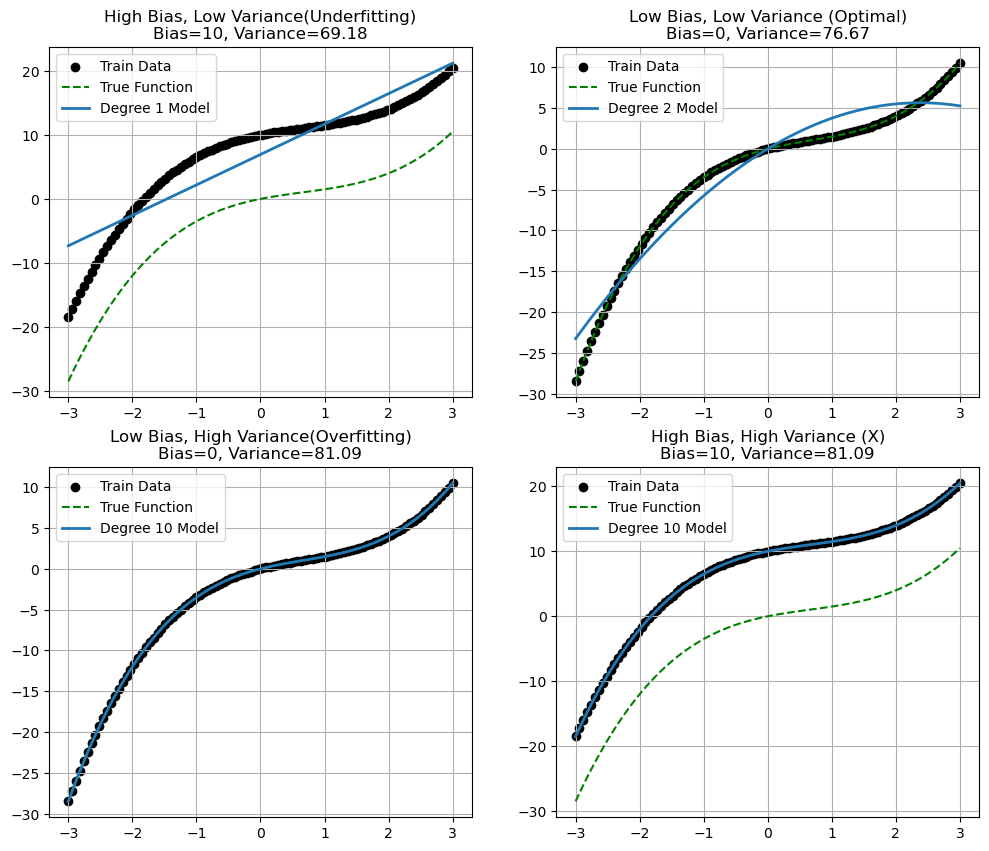

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # 전체 데이터 (100개)
y_true = 0.5 * X**3 - X**2 + 2*X  # 3차 다항식 (Noise 없음)

def generate_biased_data(X, bias_term, noise_std=0):
    return 0.5 * X**3 - X**2 + 2*X + bias_term + np.random.normal(0, noise_std, X.shape)  # Bias와 Noise 추가

def train_and_plot(degree, bias_term, train_size, noise_std, title, subplot):
    # 훈련 데이터 선택 (Train Size 조절 → Variance 변화)
    X_train = X[:train_size]
    y_train = generate_biased_data(X_train, bias_term, noise_std)

    # 모델 학습
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    # 예측
    y_pred = model.predict(X)

    # Variance 계산 (모델 예측값의 변동성 측정)
    variance = np.var(y_pred - np.mean(y_pred))

    plt.subplot(2, 2, subplot)
    plt.scatter(X_train, y_train, color="black", label=f"Train Data")  # 훈련 데이터
    plt.plot(X, y_true, label="True Function", linestyle="dashed", color="green")
    plt.plot(X, y_pred, label=f"Degree {degree} Model", linewidth=2)
    plt.legend()
    plt.title(f"{title}\nBias={bias_term}, Variance={variance:.2f}")
    plt.grid()

plt.figure(figsize=(12, 10))

# (1) High Bias, Low Variance (Underfitting) → 단순한 모델, Bias 크게 줌
train_and_plot(degree=1, bias_term=10, train_size=100, noise_std=0, title="High Bias, Low Variance(Underfitting)", subplot=1)

# (2) Low Bias, Low Variance (Optimal) → 적절한 모델, Bias 적게 줌, 충분한 데이터
train_and_plot(degree=2, bias_term=0, train_size=100, noise_std=0, title="Low Bias, Low Variance (Optimal)", subplot=2)

# (3) Low Bias, High Variance (Overfitting) → 복잡한 모델, 적은 데이터 사용
train_and_plot(degree=10, bias_term=0, train_size=100, noise_std=0, title="Low Bias, High Variance(Overfitting)", subplot=3)

# (4) High Bias, High Variance (엉망진창 모델) → 너무 단순한 모델 + 훈련 데이터 극단적으로 적음
train_and_plot(degree=10, bias_term=10, train_size=100, noise_std=0, title="High Bias, High Variance (X)", subplot=4)

plt.show()

## 데이터 균형 조정 방법

### 데이터 불균형이란?
> 분류 문제에서 클래스 간 샘플 수의 차이가 큰 경우

예) 
신용카드 사기 탐지, 희귀 질병 예측

### 언더 샘플링(Under Sampling) 
> 다수 클래스의 샘플 수를 줄이는 방법

- 장점
    - 데이터 크기가 줄어 학습 속도가 빨라 짐
    - 불필요한 데이터 제거로 overfitting 가능성 감소
- 단점
    - 중요한 정보를 가진 샘플이 제거될 가능성이 있음
    - 데이터 손실로 인해 모델 성능이 낮아질 수 있음
- 기법
    - 랜덤 언더샘플링
    - NearMiss 


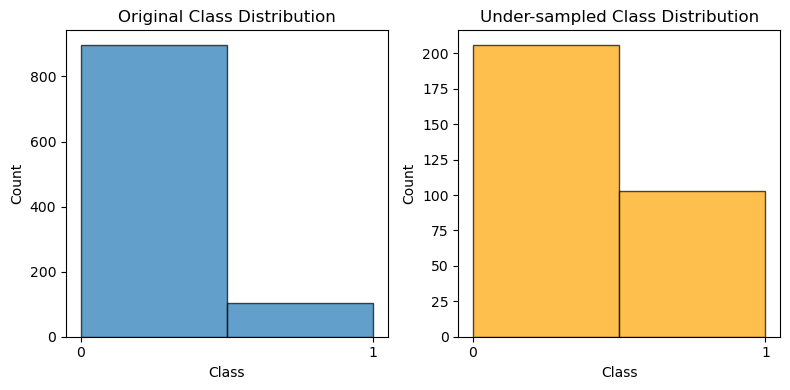

원본 데이터 클래스 비율:
 0    0.897
1    0.103
Name: proportion, dtype: float64

언더샘플링 후 클래스 비율:
 0    0.666667
1    0.333333
Name: proportion, dtype: float64


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler  # pip install imblanced-learn
from sklearn.datasets import make_classification

# 불균형 데이터 생성
X, y = make_classification(n_classes=2, weights=[0.9, 0.1], n_samples=1000, random_state=42)
df = pd.DataFrame(X, columns=[f'Feature {i}' for i in range(X.shape[1])])
df['Target'] = y

# 언더샘플링 적용
# sampling_strategy 더 많은 샘플과의 비율 / random_state 랜덤 시드 (동일한 샘플을 추출하기 위해)
#                                               - 설정하지 않으면 학습할때마다 매번 랜덤하게 샘플링
undersample = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_under, y_under = undersample.fit_resample(X, y) 

# 원본 데이터 클래스 분포 시각화
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=2, edgecolor='k', alpha=0.7)
plt.xticks([0, 1])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Original Class Distribution')

# 언더샘플링 후 데이터 클래스 분포 시각화
plt.subplot(1, 2, 2)
plt.hist(y_under, bins=2, edgecolor='k', alpha=0.7, color='orange')
plt.xticks([0, 1])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Under-sampled Class Distribution')

plt.tight_layout()
plt.show()

# 데이터 비율 출력
original_ratio = pd.Series(y).value_counts(normalize=True)
under_ratio = pd.Series(y_under).value_counts(normalize=True)
print("원본 데이터 클래스 비율:\n", original_ratio)
print("\n언더샘플링 후 클래스 비율:\n", under_ratio)

### NearMiss
    - 언더 샘플링 방식
    - 아래 3가지 버전이 있음 / 기존 데이터의 특성과 목적을 알고서 사용
#### NearMiss-1 
                - 다수 클래스중 가장 가까운 k개의 소수 클래스 샘플과 평균 거리가 가장 작은 샘플<br>
                - 경계를 명확하게 만들고 싶을때
#### NearMiss-2 
                - 다수 클래스중 가장 가까운 k개의 소수 클래스 샘플과 평균 거리가 가장 먼 샘플<br>
                - 다수 클래스의 대표성을 유지할 때
#### NearMiss-3 
                - 각 소수 클래스 샘플과 가강 가까운 다수 클래스 샘플을 일정 개수(k개)만 남기고 나머지 제거<br>
                - 균등한 분포를 만들고 싶을때

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.under_sampling import NearMiss
from sklearn.datasets import make_classification

# 가상의 불균형 데이터 생성
X, y = make_classification(n_classes=2, class_sep=2, 
                           weights=[0.9, 0.1], 
                           n_informative=3, n_redundant=1, 
                           flip_y=0, 
                           n_features=10, 
                           n_clusters_per_class=1, 
                           n_samples=1000, random_state=42)

# 원본 데이터 클래스 분포 확인
print(f"Before NearMiss: {Counter(y)}")

# NearMiss를 사용한 언더샘플링 (버전 1)
nm = NearMiss(version=1)
X_resampled, y_resampled = nm.fit_resample(X, y)    # fit_XXX : 보통 원본 데이터를 가공

# 언더샘플링 후 데이터 클래스 분포 확인
print(f"After NearMiss: {Counter(y_resampled)}")

# NearMiss를 사용한 언더샘플링 (버전 1)
nm = NearMiss(version=2)
X_resampled2, y_resampled2 = nm.fit_resample(X, y)    # fit_XXX : 보통 원본 데이터를 가공

# 언더샘플링 후 데이터 클래스 분포 확인
print(f"After NearMiss: {Counter(y_resampled2)}")

# NearMiss를 사용한 언더샘플링 (버전 1)
nm = NearMiss(version=3)
X_resampled3, y_resampled3 = nm.fit_resample(X, y)    # fit_XXX : 보통 원본 데이터를 가공

# 언더샘플링 후 데이터 클래스 분포 확인
print(f"After NearMiss: {Counter(y_resampled3)}")

Before NearMiss: Counter({np.int64(0): 900, np.int64(1): 100})
After NearMiss: Counter({np.int64(0): 100, np.int64(1): 100})
After NearMiss: Counter({np.int64(0): 100, np.int64(1): 100})
After NearMiss: Counter({np.int64(1): 100, np.int64(0): 78})


c:\Users\human\anaconda3\envs\test\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(


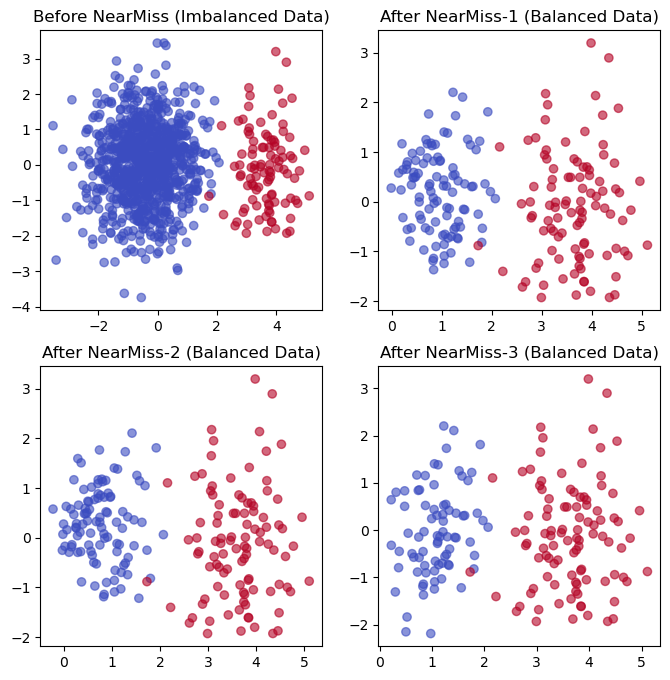

In [20]:
# 시각화 (2D PCA 변환 후 플롯)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_resampled_pca = pca.transform(X_resampled)
X_resampled_pca2 = pca.transform(X_resampled2)
X_resampled_pca3 = pca.transform(X_resampled3)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Before NearMiss (Imbalanced Data)")

plt.subplot(2, 2, 2)
plt.scatter(X_resampled_pca[:, 0], X_resampled_pca[:, 1], c=y_resampled, cmap='coolwarm', alpha=0.6)
plt.title("After NearMiss-1 (Balanced Data)")

plt.subplot(2, 2, 3)
plt.scatter(X_resampled_pca2[:, 0], X_resampled_pca2[:, 1], c=y_resampled2, cmap='coolwarm', alpha=0.6)
plt.title("After NearMiss-2 (Balanced Data)")

plt.subplot(2, 2, 4)
plt.scatter(X_resampled_pca3[:, 0], X_resampled_pca3[:, 1], c=y_resampled3, cmap='coolwarm', alpha=0.6)
plt.title("After NearMiss-3 (Balanced Data)")

plt.show()

### Quiz 1

유방암 데이터를 활용하여 NearMiss 언더 샘플링을 적용하고 클래스별 개수를 시각화 하시오

In [45]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# 데이터 로드
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 타겟(0: 양성, 1: 음성) 추가
df['target'] = data.target

In [46]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [50]:
nm = NearMiss(version=3)
X, y = nm.fit_resample(df[df.columns[:-1]], df['target'])
y.value_counts()

c:\Users\human\anaconda3\envs\test\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(


target
0    212
1     65
Name: count, dtype: int64

### 오버 샘플링(Over Sampling) 
> 소수 클래스의 샘플 수를 늘리는 방법

- 장점
    - 소스 클래스의 샘플 수가 늘어 충분한 학습이 가능
    - 데이터 손실이 없기 때문에 중요한 패턴 유지 가능
- 단점
    - 추가된 샘플 데이터의 품질에 따라 성능이 좌우될 수 있음
    - 유사한 데이터가 늘어나면 overfitting 가능성 높아짐
- 기법
    - 랜덤 오버샘플링
    - SMOTE (Synthetic Minority Over sampling Technique)


#### 랜덤 오버샘플링

Before OverSampling: Counter({np.int64(0): 900, np.int64(1): 100})
After OverSampling: Counter({np.int64(0): 900, np.int64(1): 900})


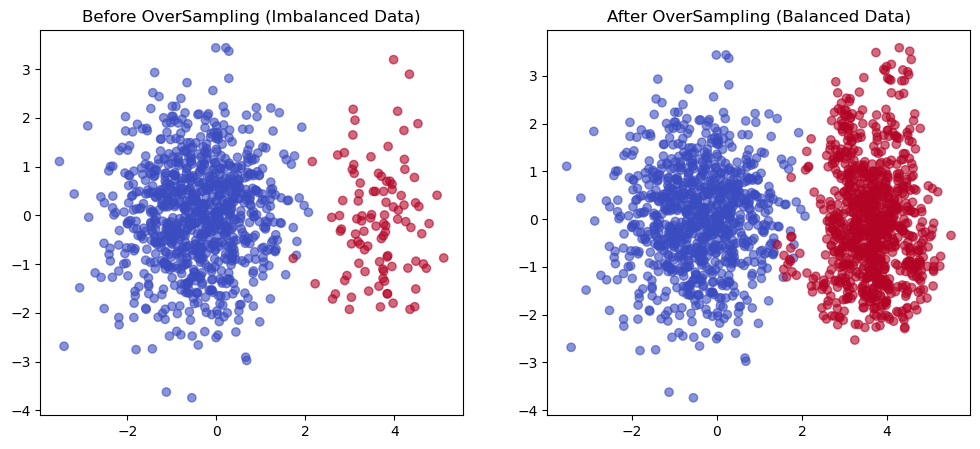

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

X, y = make_classification(n_classes=2, class_sep=2, 
                           weights=[0.9, 0.1],  # 클래스 불균형 (90:10)
                           n_informative=3, n_redundant=1, 
                           flip_y=0, n_features=10, 
                           n_clusters_per_class=1, 
                           n_samples=1000, random_state=42)

print(f"Before OverSampling: {Counter(y)}")

ros = RandomOverSampler(random_state=42, shrinkage=0.5)
X_resampled, y_resampled = ros.fit_resample(X, y)

print(f"After OverSampling: {Counter(y_resampled)}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)   # 기존 데이터는 11차원 임으로 PCA를 통해 시각화 하기 쉽게 변환
X_resampled_pca = pca.transform(X_resampled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Before OverSampling (Imbalanced Data)")

plt.subplot(1, 2, 2)
plt.scatter(X_resampled_pca[:, 0], X_resampled_pca[:, 1], c=y_resampled, cmap='coolwarm', alpha=0.6)
plt.title("After OverSampling (Balanced Data)")

plt.show()

#### SMOTE

1. 임의의 소수 클래스 샘플 선택
2. 선택된 샘플과 가까운 k개 샘플 선택
3. 처음 선택된 샘플과 가장 가까운 샘플 사이에 랜덤하게 선형 보간을 사용하여 새로운 샘플 생성 

예) 

X_1 = (2, 3) <br>
X_2 = (6, 7)

X_new = (2,3) +  0.5 * ((6,7) - (2,3)) = (4,5)

<img src="사진/smote.png" alt="smote"/>

Before SMOTE: Counter({np.int64(0): 900, np.int64(1): 100})
1000 1000
After SMOTE: Counter({np.int64(0): 900, np.int64(1): 900})
1800 1800


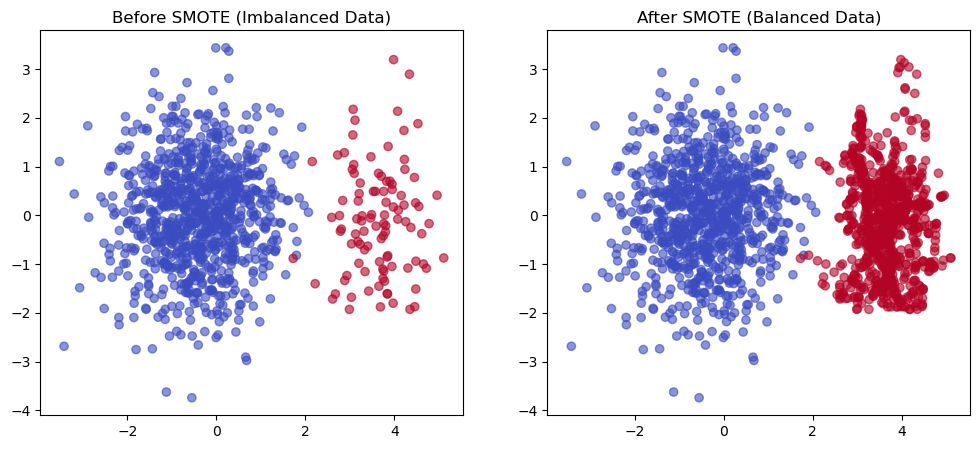

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# 가상의 불균형 데이터 생성
X, y = make_classification(n_classes=2, class_sep=2, 
                           weights=[0.9, 0.1], 
                           n_informative=3, n_redundant=1, 
                           flip_y=0, 
                           n_features=10, 
                           n_clusters_per_class=1, 
                           n_samples=1000, random_state=42)

# 원본 데이터 클래스 분포 확인
print(f"Before SMOTE: {Counter(y)}")

# SMOTE를 사용한 오버샘플링
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 오버샘플링 후 데이터 클래스 분포 확인
print(f"After SMOTE: {Counter(y_resampled)}")

# 시각화 (PCA 변환 후 플롯)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_resampled_pca = pca.transform(X_resampled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Before SMOTE (Imbalanced Data)")

plt.subplot(1, 2, 2)
plt.scatter(X_resampled_pca[:, 0], X_resampled_pca[:, 1], c=y_resampled, cmap='coolwarm', alpha=0.6)
plt.title("After SMOTE (Balanced Data)")

plt.show()

### Quiz
유방암 데이터를 활용해서 SMOTE 오버샘플링을 하시오

In [80]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# 데이터 로드
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 타겟(0: 양성, 1: 음성) 추가
df['target'] = data.target

df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [81]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(df[df.columns[:-1]], df['target'])
X_resampled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,...,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900
1,20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,...,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020
2,19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,...,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580
3,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,...,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000
4,20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,...,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,13.939670,16.889904,91.302939,600.074793,0.108469,0.127913,0.095349,0.052235,0.187674,0.061854,...,16.412871,21.916257,108.379533,824.271977,0.149917,0.329758,0.315436,0.137514,0.300714,0.082547
710,18.120774,17.733850,118.837719,1010.543540,0.101572,0.135287,0.141583,0.083303,0.189773,0.060332,...,20.485106,23.028067,134.159962,1305.854945,0.127112,0.248971,0.349358,0.143467,0.292752,0.081113
711,18.980205,20.722921,122.740052,1118.560464,0.091937,0.075621,0.104443,0.068474,0.165097,0.052002,...,20.157806,25.712240,131.990084,1253.710496,0.124484,0.144843,0.258238,0.141613,0.256907,0.061660
712,15.522588,19.646182,101.894239,751.576181,0.107754,0.121890,0.139715,0.077363,0.193186,0.059054,...,19.324746,26.925872,125.115821,1141.324170,0.154729,0.284420,0.383093,0.150645,0.308649,0.085847


## 모델 성능 개선 및 하이퍼파라미터 튜닝

모델 성능을 개선 하는 방법은 크게 4가지가 있음 

1. 데이터 품질 향상 
2. Feature Engineering 
3. 모델 선택 및 하이퍼 파라미터 튜닝
4. 앙상블

### 모델 선택 및 하이퍼 파라미터 튜닝

#### 모델 선택
> 간단한 모델부터 복잡한 모델을 까지 학습해보고 성능 비교

#### 하이퍼 파라미터 튜닝
> 하이퍼 파라미터를 변경하면서 최적의 하이퍼 파라미터를 찾는 방법 <br>
※ 하이퍼 파라미터란 사용자가 직접 설정해야 하는 파라미터 <br>
예) 학습률, 군집 개수 등

- 기법 
- Grid Search
- Random search
- Bayesian Optimization 
- Optuna

#### Grid Search
> 가능한 모든 조합을 찾아내는 방법 <br>
> 가장 확실한 방법이지만, 모든 가능성을 조합하기 때문에 시간이 많이 걸림

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 데이터 로드
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [10, 50, 100],  # 트리 개수
    'max_depth': [None, 10, 20],  # 최대 깊이
    'min_samples_split': [2, 5, 10]  # 최소 분할 샘플 수
}

# 모델 및 GridSearchCV 적용
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Best Score: 0.95


#### Random Search 
> 하이퍼파라미터 조합을 무작위로 샘플링하여 최적의 조합을 찾음. <br>
> 빠르게 할 수 있지만 정확도가 떨어지고, 시행할때마다 달라질 수 있음

In [119]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 하이퍼파라미터 후보 설정 (값의 범위를 넓게 설정)
param_dist = {
    'n_estimators': np.arange(10, 200, 10),  # 트리 개수 (10~200)
    'max_depth': [None, 10, 20, 30, 40],  # 최대 깊이
    'min_samples_split': np.arange(2, 20, 2)  # 최소 분할 샘플 수
}

# RandomizedSearchCV 적용 (n_iter=10: 10개의 조합만 탐색)
rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)     # job : 리소스 (이 코드에서는 CPU)
random_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': np.int64(100), 'min_samples_split': np.int64(8), 'max_depth': None}
Best Score: 0.95


#### Bayesian Optimization (베이지안 최적화)
> 이전 탐색 결과를 활용하여 더 나은 조합을 찾는 방식. <br>

In [6]:
from skopt import BayesSearchCV # pip install scikit-optimize

# 하이퍼파라미터 탐색 범위 설정
param_space = {
    'n_estimators': (10, 200),  # 트리 개수 (연속형 범위)
    'max_depth': (1, 40),  # 최대 깊이
    'min_samples_split': (2, 20)  # 최소 분할 샘플 수
}

# BayesSearchCV 적용
rf = RandomForestClassifier(random_state=42)
bayes_search = BayesSearchCV(rf, param_space, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
bayes_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", bayes_search.best_params_)
print("Best Score:", bayes_search.best_score_)

Best Parameters: OrderedDict({'max_depth': 17, 'min_samples_split': 15, 'n_estimators': 187})
Best Score: 0.95


### Optuna (AutoML 기반 최적화)
> Tree-structured Parzen Estimator (TPE)를 사용하여 탐색.<br>
        - 기본적으로 속도가 가장 빠름

In [121]:
import optuna # pip install optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 최적화할 목적 함수 정의
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)  # 트리 개수
    max_depth = trial.suggest_int('max_depth', 1, 40)  # 최대 깊이
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)  # 최소 분할 샘플 수

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    
    # 교차 검증 점수 계산
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score

# Optuna 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)  # 20번 탐색

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", study.best_params)
print("Best Score:", study.best_value)

[I 2025-03-14 14:14:55,484] A new study created in memory with name: no-name-fb4f9750-edb2-4b37-849e-07214f9c58fc
[I 2025-03-14 14:14:56,314] Trial 0 finished with value: 0.9416666666666667 and parameters: {'n_estimators': 106, 'max_depth': 29, 'min_samples_split': 2}. Best is trial 0 with value: 0.9416666666666667.
[I 2025-03-14 14:14:57,319] Trial 1 finished with value: 0.95 and parameters: {'n_estimators': 138, 'max_depth': 19, 'min_samples_split': 10}. Best is trial 1 with value: 0.95.
[I 2025-03-14 14:14:57,425] Trial 2 finished with value: 0.9333333333333333 and parameters: {'n_estimators': 12, 'max_depth': 15, 'min_samples_split': 18}. Best is trial 1 with value: 0.95.
[I 2025-03-14 14:14:58,521] Trial 3 finished with value: 0.95 and parameters: {'n_estimators': 151, 'max_depth': 26, 'min_samples_split': 15}. Best is trial 1 with value: 0.95.
[I 2025-03-14 14:15:00,098] Trial 4 finished with value: 0.95 and parameters: {'n_estimators': 180, 'max_depth': 10, 'min_samples_split': 

Best Parameters: {'n_estimators': 138, 'max_depth': 19, 'min_samples_split': 10}
Best Score: 0.95


## 비지도 학습 워크 플로우

### 비지도 학습 두 가지 분류 

#### 군집 분석 (Clustering)
> 군집 분석은 유사한 데이터끼리 그룹화 하는 기법

예) 
- K-means Clustering, DBSCAN(Density-Based Clustering)
- https://blog.naver.com/bi_matrix/222401361622 (k-means)
- https://bcho.tistory.com/1205 (DBSCAN)


#### 차원 축소 (Dimensionality Reduction)
> 고차원 데이터를 저차원으로 변환 하면서 주요 정보를 유지하는 기법
> 축소된 공간에서 자연스럽게 유사한 데이터끼리 그룹화됨

예) 
- PCA, t-SNE, UMAP

### Elbow Method 
> 클러스터 개수를 변화 시키면서 K-Means의 관성(Inertia)을 확인하는 방법 <br>
> K 값을 늘리면서 Inertia 값이 급격히 줄어드는 지점이 최적의 k값 <br>
> 클러스터 개수가 증가할수록 오차 제곱합(SSE, Sum of Squared Errors)이 감소하는 원리 <br>
> SSE 값이 작아지면 데이터가 중심에 더 가까이 모여있음

※	관성(Inertia)란, 각 데이터 포인트가 가장 가까운 클러스터 중심과의 거리의 제곱 합

<img src="사진/elbow.png" width=500 height=350 alt="elbow"/>

In [90]:
import optuna # pip install optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 최적화할 목적 함수 정의
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)  # 트리 개수
    max_depth = trial.suggest_int('max_depth', 1, 40)  # 최대 깊이
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)  # 최소 분할 샘플 수

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    
    # 교차 검증 점수 계산
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score

# Optuna 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)  # 20번 탐색

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", study.best_params)
print("Best Score:", study.best_value)

[I 2025-03-14 12:15:48,893] A new study created in memory with name: no-name-cf28389e-a142-4be1-a2d8-3a01902a801a
[I 2025-03-14 12:15:49,403] Trial 0 finished with value: 0.95 and parameters: {'n_estimators': 65, 'max_depth': 22, 'min_samples_split': 4}. Best is trial 0 with value: 0.95.
[I 2025-03-14 12:15:49,696] Trial 1 finished with value: 0.95 and parameters: {'n_estimators': 35, 'max_depth': 36, 'min_samples_split': 5}. Best is trial 0 with value: 0.95.
[I 2025-03-14 12:15:50,626] Trial 2 finished with value: 0.85 and parameters: {'n_estimators': 130, 'max_depth': 1, 'min_samples_split': 7}. Best is trial 0 with value: 0.95.
[I 2025-03-14 12:15:51,232] Trial 3 finished with value: 0.95 and parameters: {'n_estimators': 74, 'max_depth': 17, 'min_samples_split': 8}. Best is trial 0 with value: 0.95.
[I 2025-03-14 12:15:52,129] Trial 4 finished with value: 0.95 and parameters: {'n_estimators': 121, 'max_depth': 6, 'min_samples_split': 12}. Best is trial 0 with value: 0.95.
[I 2025-03

Best Parameters: {'n_estimators': 14, 'max_depth': 13, 'min_samples_split': 2}
Best Score: 0.9583333333333334


### Silhouette Score
> 클러스터링이 얼마나 잘 되었는지 평가하는 지표 <br>
> 데이터 포인트가 자신이 속한 클러스터와 얼마나 가까운지, 다른 클러스터와 얼마나 먼지 비교하여 계산 <br>
> 값의 범위 -1 ~ 1 <br>

- 1에 가까울 수록 좋은 클러스터링
- 0에 가까우면 클러스터링이 겹쳐 있음
- -1에 가까우면 잘못된 클러스터링


데이터 샘플:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

결측치 확인:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

기본 통계 요약:
        sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
ma

c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

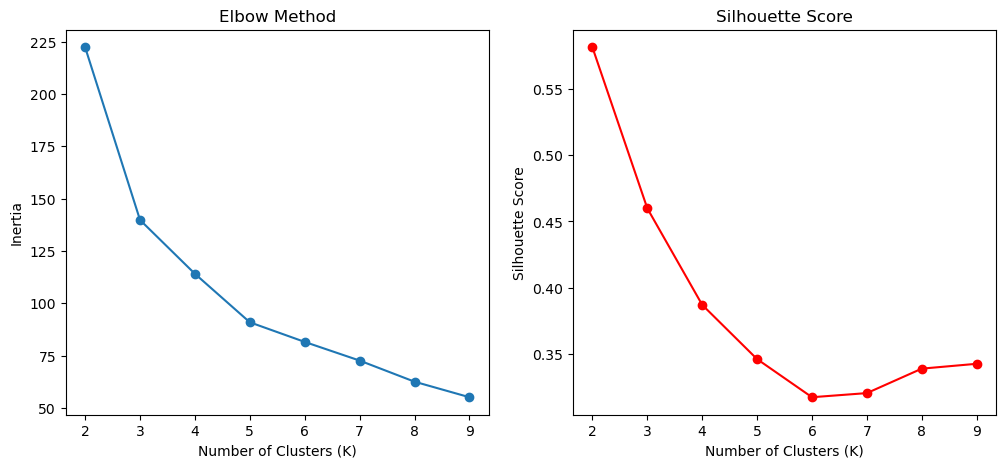

c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means Silhouette Score: 0.4599
DBSCAN Silhouette Score: 0.5979


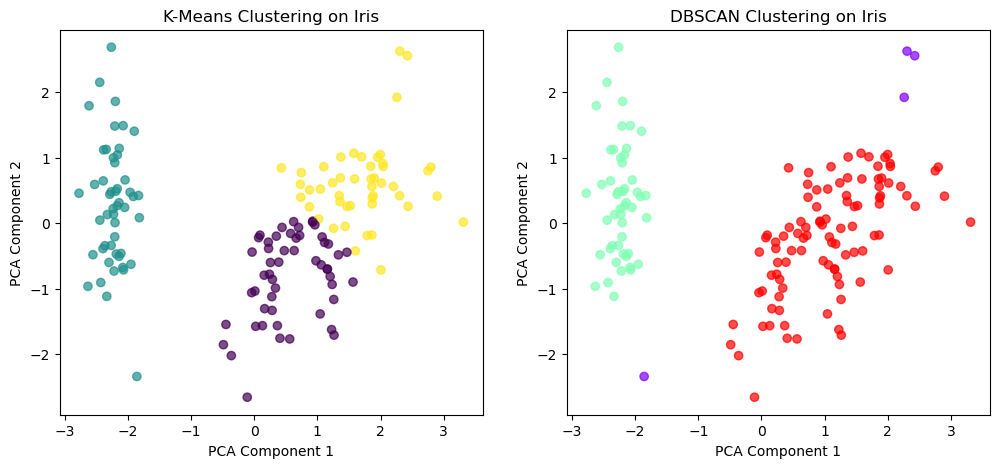

In [94]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. 데이터 로드
df = sns.load_dataset("iris")

# 2. 데이터 탐색 (EDA)
print("데이터 샘플:\n", df.head())
print("\n결측치 확인:\n", df.isnull().sum())
print("\n기본 통계 요약:\n", df.describe())

# 3. Data Cleaning (결측치 처리)
df.dropna(inplace=True)  # 결측치 제거

# 4. Feature Engineering (특징 선택 & Scaling)
X = df.drop(columns=['species'])  # 비지도 학습이므로 라벨 제거
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # 표준화 적용

# 5. 최적의 K 찾기 (Elbow Method & Silhouette Score)
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow Method 시각화
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Silhouette Score 시각화
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()

# 최적 K 선택 (Elbow & Silhouette Score 결과 기반)
optimal_k = 3  

# 6. 훈련/테스트 데이터 셋 분리 (비지도 학습에서는 따로 하지 않음)
# -> 지도 학습과 다르게 정답(레이블)이 없으므로 전체 데이터를 클러스터링에 사용

# 7. 모델 학습 (K-Means 클러스터링)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 7-2. 모델 학습 (DBSCAN)
dbscan = DBSCAN(eps=0.8, min_samples=4) # eps: epsilon의 약자로 임의의 점 p로 부터 떨어진 거리 / min_samples: eps 거리내 데이터 개수 
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# 8. 모델 평가 (Silhouette Score)
kmeans_silhouette = silhouette_score(X_scaled, df['Cluster_KMeans'])
dbscan_silhouette = silhouette_score(X_scaled[df['Cluster_DBSCAN'] != -1], df['Cluster_DBSCAN'][df['Cluster_DBSCAN'] != -1])  # 노이즈 제외 후 평가

print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")

# 9. PCA 차원 축소 및 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12,5))

# K-Means 시각화
plt.subplot(1, 2, 1)
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_KMeans'], cmap='viridis', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering on Iris")

# DBSCAN 시각화
plt.subplot(1, 2, 2)
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_DBSCAN'], cmap='rainbow', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clustering on Iris")

plt.show()

## 회귀 문제 머신러닝 워크 플로우

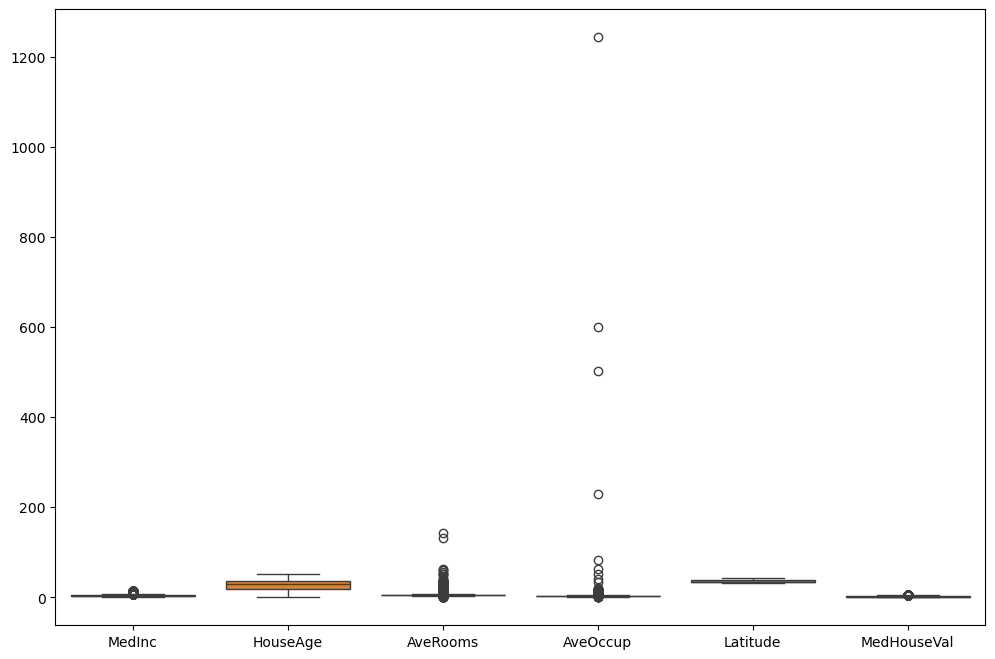

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 로드 
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

plt.figure(figsize=(12, 8))
sns.boxplot(data=df.loc[:, ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'MedHouseVal']])
plt.show()

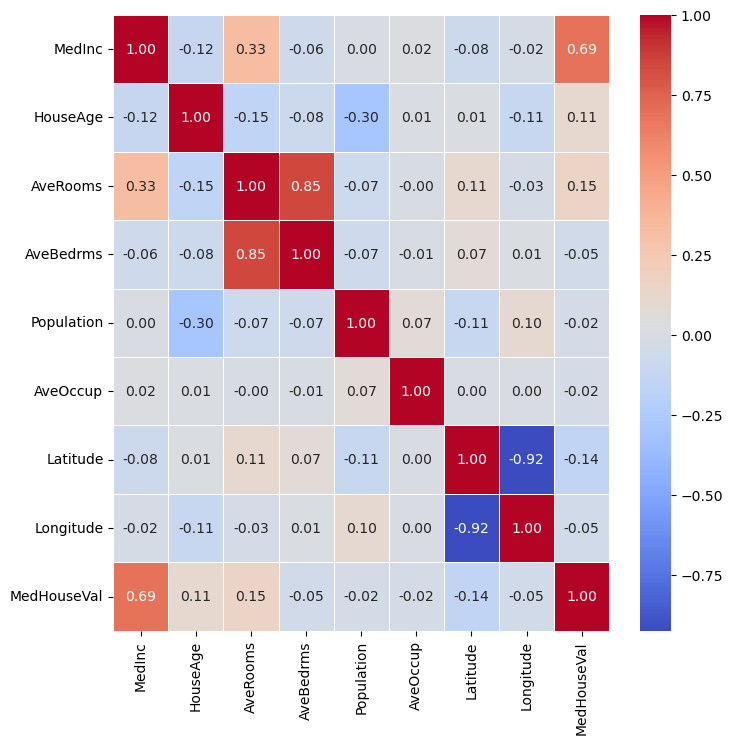

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,MedHouseVal
0,8.3252,41.0,6.984127,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,37.85,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,37.85,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,6.114035,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,5.205543,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,5.329513,741.0,2.123209,39.43,0.847


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 로드 
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

# 2. 데이터 탐색 (EDA) 
correlation_matrix = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.show()
# 3. Data Cleaning 

df.drop(columns=['Longitude', 'AveBedrms'], inplace=True)
df.drop(index=[3364, 13034, 16669, 19006])
# df.loc[df.AveOccup > 200, :]

In [63]:
# 4. Feature Engineering 
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(pd.DataFrame(y))

# 5. 훈련/테스트 데이터 셋 분리 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 6. 모델 학습 
param_space = {
    'n_estimators': (10, 200),  # 트리 개수 (연속형 범위)
    'max_depth': (1, 40),  # 최대 깊이
    'min_samples_split': (2, 20)  # 최소 분할 샘플 수
}

model = RandomForestRegressor(random_state=42)
bayes_search = BayesSearchCV(model, param_space, n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
print(type(X_train), type(y_train))

bayes_search.fit(X_train, y_train)

# 7. 모델 평가  
y_pred = bayes_search.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"회귀 모델 RMSE: {rmse:.4f}")

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


회귀 모델 RMSE: 0.5193


In [47]:
from lightgbm import LGBMRegressor

# 4. Feature Engineering 
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. 훈련/테스트 데이터 셋 분리 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LGBMRegressor()
model.fit(X_train, y_train)

# 7. 모델 평가  
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"회귀 모델 RMSE: {mse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 6
[LightGBM] [Info] Start training from score 2.071947
회귀 모델 RMSE: 0.3313


c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [66]:
model = RandomForestRegressor(random_state=42)
bayes_search = BayesSearchCV(model, param_space, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)
print(type(X_train), type(y_train))

bayes_search.fit(X_train, y_train)

# 7. 모델 평가  
y_pred = bayes_search.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"회귀 모델 RMSE: {rmse:.4f}")

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


KeyboardInterrupt: 

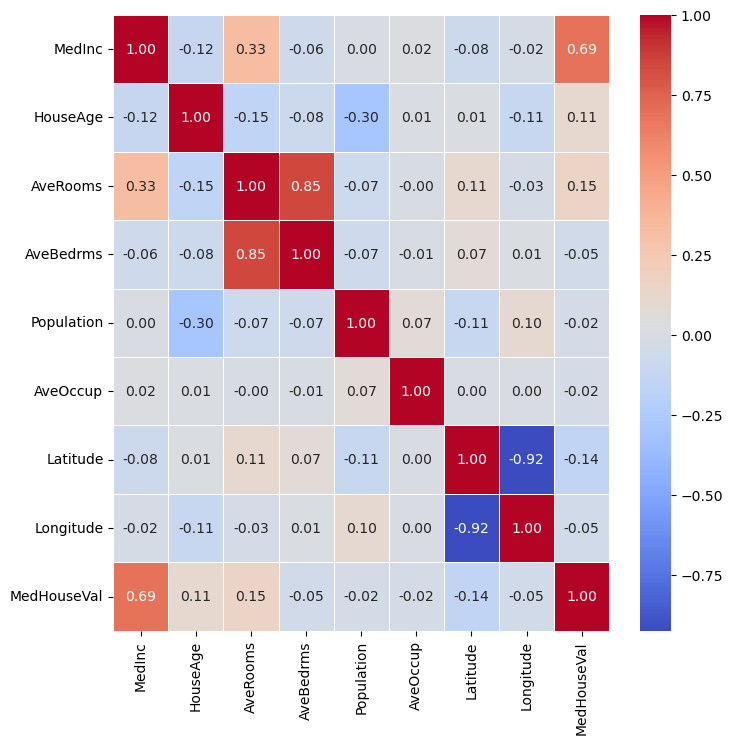

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 로드 
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

# 2. 데이터 탐색 (EDA) 
correlation_matrix = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.show()
# 3. Data Cleaning 

df.drop(columns=['Longitude', 'AveBedrms'], inplace=True)
df.drop(index=[3364, 13034, 16669, 19006])

df["MedHouseVal"] = KBinsDiscretizer(n_bins=20, encode="ordinal", strategy="quantile").fit_transform(df[["MedHouseVal"]])

In [ ]:
# 4. Feature Engineering 
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. 훈련/테스트 데이터 셋 분리 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. 모델 학습 
param_space = {
    'n_estimators': (10, 200),  # 트리 개수 (연속형 범위)
    'max_depth': (1, 40),  # 최대 깊이
    'min_samples_split': (2, 20)  # 최소 분할 샘플 수
}

model = RandomForestClassifier(random_state=42)
bayes_search = BayesSearchCV(model, param_space, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
print(type(X_train), type(y_train))

bayes_search.fit(X_train, y_train)

# 7. 모델 평가  
y_pred = bayes_search.predict(X_test)
accuracy = (y_pred == y_test).mean()

print(f"분류 모델 정확도: {accuracy:.4f}")

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [64]:
bayes_search.fit(X_train, y_train)

c:\Users\human\anaconda3\envs\test\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BayesSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_iter=20,
              n_jobs=-1, random_state=42, scoring='neg_mean_squared_error',
              search_spaces={'max_depth': (1, 40), 'min_samples_split': (2, 20),
                             'n_estimators': (10, 200)})

np.float64(0.0)

In [152]:
pd.Series(y_pred)

0        0.0
1        0.0
2       19.0
3       15.0
4        2.0
        ... 
4123    11.0
4124     1.0
4125    19.0
4126     1.0
4127     7.0
Length: 4128, dtype: float64

In [153]:
y_test

20046     0.0
3024      0.0
15663    19.0
20484    12.0
9814     15.0
         ... 
15362    14.0
16623    15.0
18086    19.0
2144      1.0
3665      7.0
Name: MedHouseVal, Length: 4128, dtype: float64

In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')  # use_label_encoder 제거 (기본 False)

# 하이퍼파라미터 후보 설정
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 1000],  
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'max_depth': [3, 5, 7, 9, 11, 13],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1, 5, 10],
    'reg_lambda': [0.1, 1, 5, 10, 50],
    'scale_pos_weight': [1, 10, 25, 50, 100],  # 불균형 클래스 조정
    'max_delta_step': [0, 1, 5, 10]
}

# RandomizedSearchCV 적용
random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_distributions, 
    n_iter=50,  # 시도 횟수
    cv=5,  # 5-폴드 교차 검증
    scoring='f1_macro',  # 분류 지표 유지
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# 모델 학습
random_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터와 점수 출력
print("Best Parameters:", random_search.best_params_)
print("Best Score (F1 Macro):", random_search.best_score_)

# 테스트 데이터로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
# 분류 보고서 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

NameError: name 'RandomizedSearchCV' is not defined

## 부동산 허위매물 분류 (데이콘)

[출처]: https://dacon.io/competitions/official/236439/overview/description

In [94]:
import pandas as pd

In [152]:
train = pd.read_csv('data/부동산 허위매물 분류/train.csv')
test = pd.read_csv('data/부동산 허위매물 분류/test.csv')

In [144]:
train.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      787
해당층       229
총층         16
방향          0
방수         16
욕실수        18
주차가능여부      0
총주차대수     696
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
허위매물여부      0
dtype: int64

In [153]:
train.interpolate(inplace=True)
indexs = [i for i in np.where(train['해당층'] > train['총층'])[0]]
train.drop(index=indexs, inplace=True)
train.dropna(inplace=True)
train.drop(columns=['게재일', '중개사무소', '제공플랫폼', 'ID'], inplace=True)
train = pd.get_dummies(train, columns=['방향', '주차가능여부', '매물확인방식'], drop_first=True)
train['전용면적'] = train['전용면적'].astype(int)
train['해당층'] = train['해당층'].astype(int)
train['총층'] = train['총층'].astype(int)
train['방수'] = train['방수'].astype(int)
train['욕실수'] =train['욕실수'].astype(int)
train['총주차대수'] = train['총주차대수'].astype(int)
train['보증금'] = train['보증금'].astype(int)
train['월세'] = train['월세'].astype(int)

C:\Users\human\AppData\Local\Temp\ipykernel_8988\287054228.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train.interpolate(inplace=True)


In [154]:
train.head()

,보증금,월세,전용면적,해당층,총층,방수,욕실수,총주차대수,관리비,허위매물여부,방향_남서향,방향_남향,방향_동향,방향_북동향,방향_북서향,방향_북향,방향_서향,주차가능여부_불가능,매물확인방식_전화확인,매물확인방식_현장확인
3,163500000,30000,36,3,9,2,1,13,10,0,False,False,False,False,False,False,False,False,False,True
4,346000000,530000,32,3,3,2,1,7,0,1,False,False,True,False,False,False,False,True,False,True
5,153000000,530000,29,2,3,2,1,1,0,0,False,True,False,False,False,False,False,False,True,False
6,348500000,400000,30,2,3,1,1,6,0,0,False,False,False,True,False,False,False,True,False,True
7,139500000,590000,30,2,3,2,1,12,0,0,False,False,True,False,False,False,False,True,False,True


In [155]:
# 4. Feature Engineering 
X = train.drop(columns=['허위매물여부'])
y = train['허위매물여부']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. 훈련/테스트 데이터 셋 분리 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. 모델 학습 
param_space = {
    'n_estimators': (10, 200),  # 트리 개수 (연속형 범위)
    'max_depth': (1, 40),  # 최대 깊이
    'min_samples_split': (2, 20)  # 최소 분할 샘플 수
}

model = RandomForestClassifier(random_state=42)
bayes_search = BayesSearchCV(model, param_space, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
print(type(X_train), type(y_train))

bayes_search.fit(X_train, y_train)

# 7. 모델 평가  
y_pred = bayes_search.predict(X_test)
accuracy = (y_pred == y_test).mean()

print(f"분류 모델 정확도: {accuracy:.4f}")

<class 'numpy.ndarray'> <class 'pandas.core.series.Series'>
분류 모델 정확도: 0.9064


In [54]:
test.isna().sum()

ID          0
매물확인방식      0
보증금         0
월세          0
전용면적      184
해당층        50
총층          2
방향          0
방수          2
욕실수         2
주차가능여부      0
총주차대수     175
관리비         0
중개사무소       0
제공플랫폼       0
게재일         0
dtype: int64

In [156]:
X_test

array([[-0.47130421, -1.31414908, -0.32563663, ..., -0.99170798,
        -0.42875914,  0.66140955],
       [ 0.0572155 , -1.31414908,  0.62262356, ..., -0.99170798,
        -0.42875914, -1.51192252],
       [ 1.46935411,  1.25332323, -0.73203385, ...,  1.00836135,
         2.33231179, -1.51192252],
       ...,
       [-0.71904783,  0.57512299,  0.7580893 , ..., -0.99170798,
        -0.42875914,  0.66140955],
       [ 0.28018476,  0.47823725,  0.21622633, ..., -0.99170798,
        -0.42875914,  0.66140955],
       [ 0.3173463 , -0.7328346 ,  1.29995226, ..., -0.99170798,
        -0.42875914,  0.66140955]], shape=(481, 19))

In [157]:
test.interpolate(inplace=True)
indexs = [i for i in np.where(test['해당층'] > test['총층'])[0]]
test.drop(index=indexs, inplace=True)
test.dropna(inplace=True)
test.drop(columns=['게재일', '중개사무소', '제공플랫폼', 'ID'], inplace=True)
test = pd.get_dummies(test, columns=['방향', '주차가능여부', '매물확인방식'], drop_first=True)
test['전용면적'] = test['전용면적'].astype(int)
test['해당층'] = test['해당층'].astype(int)
test['총층'] = test['총층'].astype(int)
test['방수'] = test['방수'].astype(int)
test['욕실수'] = test['욕실수'].astype(int)
test['총주차대수'] = test['총주차대수'].astype(int)
test['보증금'] = test['보증금'].astype(int)
test['월세'] = test['월세'].astype(int)
scaler = StandardScaler()
test_scaled = scaler.fit_transform(test)


C:\Users\human\AppData\Local\Temp\ipykernel_8988\78164805.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  test.interpolate(inplace=True)


In [ ]:
y_pred = bayes_search.predict(test_scaled)


,보증금,월세,전용면적,해당층,총층,방수,욕실수,총주차대수,관리비,방향_남서향,방향_남향,방향_동향,방향_북동향,방향_북서향,방향_북향,방향_서향,주차가능여부_불가능,매물확인방식_전화확인,매물확인방식_현장확인
1,150500000,590000,30,7,11,1,1,16,11,False,False,False,False,False,False,True,True,False,False
2,47000000,200000,41,2,3,2,1,22,0,True,False,False,False,False,False,False,True,False,True
3,133000000,250000,31,5,6,2,1,28,5,False,True,False,False,False,False,False,False,False,False
4,108000000,380000,23,2,3,1,1,35,0,False,True,False,False,False,False,False,True,False,True
6,64500000,370000,19,8,8,1,1,48,5,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,152500000,340000,30,4,6,1,1,1,2,False,False,False,False,False,False,False,False,False,True
609,226500000,750000,29,4,10,2,1,34,7,True,False,False,False,False,False,False,False,True,False
610,169500000,500000,30,5,6,1,1,33,6,False,True,False,False,False,False,False,True,False,True
611,180000000,340000,17,3,6,1,1,2,8,False,False,False,False,False,False,False,False,False,True


In [159]:
test_scaled

array([[ 0.00770007,  1.00125889,  0.35645274, ...,  1.00495461,
        -0.3839896 , -1.62318531],
       [-0.94176607, -0.86657419,  1.82470376, ...,  1.00495461,
        -0.3839896 ,  0.6160726 ],
       [-0.15283768, -0.62710841,  0.4899301 , ..., -0.99506981,
        -0.3839896 , -1.62318531],
       ...,
       [ 0.1819982 ,  0.57022049,  0.35645274, ...,  1.00495461,
        -0.3839896 ,  0.6160726 ],
       [ 0.27832085, -0.19607   , -1.37875302, ..., -0.99506981,
        -0.3839896 ,  0.6160726 ],
       [-0.06110182, -0.10028369, -0.84484356, ..., -0.99506981,
        -0.3839896 ,  0.6160726 ]], shape=(607, 19))

In [166]:
test = pd.read_csv('data/부동산 허위매물 분류/test.csv')
tt = test['ID']
len(y_pred)
tt.info

<bound method Series.info of 0      TEST_000
1      TEST_001
2      TEST_002
3      TEST_003
4      TEST_004
         ...   
608    TEST_608
609    TEST_609
610    TEST_610
611    TEST_611
612    TEST_612
Name: ID, Length: 613, dtype: object>